<a href="https://colab.research.google.com/github/mariliazago0/fundamentos01/blob/main/notebooks/encontro01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
!pip install tinydb

In [44]:
# programas/bibliotecas utilizados no script/codigo
import httpx # Responsável pelas requisições web
from bs4 import BeautifulSoup # Responsável por realizar o web scraping (coletar os dados)
from tinydb import TinyDB, Query

In [45]:
def inserir_no_banco(dados, link_noticia):
  arquivo_banco_dados = "nota_china.json"
  db = TinyDB(arquivo_banco_dados)


  # Evitar dados repetidos no banco
  Buscar = Query()
  verificar_link = db.contains(Buscar.link == link_noticia)

  if not verificar_link:
    print("Inserindo nova informação no banco")
    db.insert(dados)
  else:
    print("Link já existe no banco. Esta informação não será inserida novamente")

In [46]:
# Variável e tipos de dados (string, lista, numero)
paginas = ["https://english.news.cn/list/china-science.htm"]

def acessa_pagina (link):
  print (f"Estamos na pagina:{link}")

  # Define headers para a requisição, simulando um navegador
  headers = {
      'User-Agent': "Mozilla/50 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36",
      'Accept-Language': 'en-US,en;q=0.9',
      'Accept-Encoding': 'gzip, deflate, br',
      'Connection': 'keep-alive',
  }

  timeout = httpx.Timeout(connect=20.0, read=30.0, write=20.0, pool=10.0)
  pag_web = httpx.get(link, headers=headers, timeout=timeout)
  bs = BeautifulSoup(pag_web, "html.parser")
  return bs

# loop for
# beautifulsoap >> find e find_all

for pagina in paginas:
  pagina_inteira = acessa_pagina(pagina)
  lista_noticias = pagina_inteira.find("div", attrs={"class": "part"}).find_all("div", attrs={"class": "item"})
  for noticia in lista_noticias:

    # titulo
    try:
      titulo = noticia.find("div", attrs={"class": "tit"}).text.strip()
      print(titulo)
    except:
        titulo = ""

    #link
    try:
      link_noticia = "https://english.news.cn/" + noticia.a["href"]
      print(link_noticia)
    except:
      link_noticia = ""

    # data
    # horário
    data = ""
    hora = ""
    data_hora_elements = noticia.find_all("span",attrs={"class": "time"})
    if data_hora_elements:
      data_hora_text = data_hora_elements[0].text.strip()
      partes_tempo = data_hora_text.split(" ")
      data = partes_tempo[0] if len(partes_tempo) > 0 else ""
      hora = partes_tempo[1] if len(partes_tempo) > 1 else ""
    print(data)
    print(hora)

    conteudo = acessa_pagina (link_noticia)
    paragrafos = conteudo.find("div", attrs={"id" : "detailContent"}).find_all("p")
    lista_paragrafos = []
    for paragrafo in paragrafos:
      lista_paragrafos.append(paragrafo.text.strip())
    print(lista_paragrafos)
    # função para inserir dados coletados no banco
    dados = {
        "titulo": titulo,
        "link": link_noticia,
        "data": data,
        "hora": hora,
        "paragrafo": lista_paragrafos
    }
    print("###")
    inserir_no_banco(dados,link_noticia)

Estamos na pagina:https://english.news.cn/list/china-science.htm
Chinese scientists unveil young pulsar's origin in galactic halo2026-05-19 23:41:00
https://english.news.cn/../20260519/129203fe7dc64858bc47e2e15825b5e8/c.html
2026-05-19
23:41:00
Estamos na pagina:https://english.news.cn/../20260519/129203fe7dc64858bc47e2e15825b5e8/c.html
["URUMQI, May 19 (Xinhua) -- Chinese astronomers have unveiled the mysterious origins of a young pulsar located in the Milky Way's halo, providing compelling observational evidence for the study of such objects' formation.", 'The study, conducted by a team from the Xinjiang Astronomical Observatory (XAO) of the Chinese Academy of Sciences, was recently published in the Astrophysical Journal.', 'By utilizing long-term observational data from China\'s Five-hundred-meter Aperture Spherical Radio Telescope (FAST), also known as the "China Sky Eye," and the 26-meter Nanshan Radio Telescope, the team tracked minute changes in the position of the young pulsar,

In [47]:
import pandas as pd
import json

## Abrindo o rquivo json
with open("nota_china.json") as f:
  raw = json.load(f)

df = pd.DataFrame.from_dict(raw["_default"], orient="index")

df

,titulo,link,data,hora,paragrafo
1,Chinese scientists unveil young pulsar's origi...,https://english.news.cn/../20260519/129203fe7d...,2026-05-19,23:41:00,"[URUMQI, May 19 (Xinhua) -- Chinese astronomer..."
2,Successful launch in landmark China-Europe joi...,https://english.news.cn/../20260519/0444beac69...,2026-05-19,16:12:45,"[KOUROU, French Guiana, May 19 (Xinhua) -- The..."
3,China Focus: SMILE in sky: a new chapter in Ch...,https://english.news.cn/../20260519/7fb5d6813f...,2026-05-19,14:44:30,"[, A Vega-C rocket carrying the Solar wind Mag..."
4,Urgent: China-Europe joint SMILE satellite mis...,https://english.news.cn/../20260519/dfbdc1d70e...,2026-05-19,13:01:45,"[KOUROU, French Guiana, May 19 (Xinhua) -- The..."
5,Flash: China-Europe joint SMILE satellite miss...,https://english.news.cn/../20260519/fc6f7cad5c...,2026-05-19,12:54:30,[Flash: China-Europe joint SMILE satellite mis...
6,Across China: New study provides scientific ba...,https://english.news.cn/../20260519/98e358eb10...,2026-05-19,11:38:30,"[LANZHOU, May 19 (Xinhua) -- A new study by Ch..."
7,China Focus: China hits new milestone in space...,https://english.news.cn/../20260518/ef73f01d75...,2026-05-18,21:50:00,"[XI'AN, May 18 (Xinhua) -- Chinese scientists ..."
8,"Across China: Chinese researchers construct ""b...",https://english.news.cn/../20260518/e2a0dac2da...,2026-05-18,19:12:15,"[BEIJING, May 18 (Xinhua) -- Chinese researche..."
9,China Focus: Chinese scientists unveil decadal...,https://english.news.cn/../20260518/deb11b378f...,2026-05-18,19:05:45,"[LANZHOU, May 18 (Xinhua) -- A new study by Ch..."
10,China's satellite navigation industry reports ...,https://english.news.cn/../20260518/aa5c4de684...,2026-05-18,15:51:00,"[BEIJING, May 18 (Xinhua) -- China's satellite..."


In [48]:
# saber quantidade de linhas e colunas do dataframe
df.shape

(20, 5)

In [49]:
# saber colunas disponiveis
df.columns

Index(['titulo', 'link', 'data', 'hora', 'paragrafo'], dtype='object')

In [50]:
# selecionar uma coluna em especifico
df["titulo"]

,titulo
1,Chinese scientists unveil young pulsar's origi...
2,Successful launch in landmark China-Europe joi...
3,China Focus: SMILE in sky: a new chapter in Ch...
4,Urgent: China-Europe joint SMILE satellite mis...
5,Flash: China-Europe joint SMILE satellite miss...
6,Across China: New study provides scientific ba...
7,China Focus: China hits new milestone in space...
8,"Across China: Chinese researchers construct ""b..."
9,China Focus: Chinese scientists unveil decadal...
10,China's satellite navigation industry reports ...


In [51]:
# delimitar colunas do dataframe
df_delimitado = df[["titulo", "data"]]
df_delimitado

,titulo,data
1,Chinese scientists unveil young pulsar's origi...,2026-05-19
2,Successful launch in landmark China-Europe joi...,2026-05-19
3,China Focus: SMILE in sky: a new chapter in Ch...,2026-05-19
4,Urgent: China-Europe joint SMILE satellite mis...,2026-05-19
5,Flash: China-Europe joint SMILE satellite miss...,2026-05-19
6,Across China: New study provides scientific ba...,2026-05-19
7,China Focus: China hits new milestone in space...,2026-05-18
8,"Across China: Chinese researchers construct ""b...",2026-05-18
9,China Focus: Chinese scientists unveil decadal...,2026-05-18
10,China's satellite navigation industry reports ...,2026-05-18


In [52]:
# primeiras (head), ultimas (tail) e linhas aleatórias (sample)
df.head(10)

,titulo,link,data,hora,paragrafo
1,Chinese scientists unveil young pulsar's origi...,https://english.news.cn/../20260519/129203fe7d...,2026-05-19,23:41:00,"[URUMQI, May 19 (Xinhua) -- Chinese astronomer..."
2,Successful launch in landmark China-Europe joi...,https://english.news.cn/../20260519/0444beac69...,2026-05-19,16:12:45,"[KOUROU, French Guiana, May 19 (Xinhua) -- The..."
3,China Focus: SMILE in sky: a new chapter in Ch...,https://english.news.cn/../20260519/7fb5d6813f...,2026-05-19,14:44:30,"[, A Vega-C rocket carrying the Solar wind Mag..."
4,Urgent: China-Europe joint SMILE satellite mis...,https://english.news.cn/../20260519/dfbdc1d70e...,2026-05-19,13:01:45,"[KOUROU, French Guiana, May 19 (Xinhua) -- The..."
5,Flash: China-Europe joint SMILE satellite miss...,https://english.news.cn/../20260519/fc6f7cad5c...,2026-05-19,12:54:30,[Flash: China-Europe joint SMILE satellite mis...
6,Across China: New study provides scientific ba...,https://english.news.cn/../20260519/98e358eb10...,2026-05-19,11:38:30,"[LANZHOU, May 19 (Xinhua) -- A new study by Ch..."
7,China Focus: China hits new milestone in space...,https://english.news.cn/../20260518/ef73f01d75...,2026-05-18,21:50:00,"[XI'AN, May 18 (Xinhua) -- Chinese scientists ..."
8,"Across China: Chinese researchers construct ""b...",https://english.news.cn/../20260518/e2a0dac2da...,2026-05-18,19:12:15,"[BEIJING, May 18 (Xinhua) -- Chinese researche..."
9,China Focus: Chinese scientists unveil decadal...,https://english.news.cn/../20260518/deb11b378f...,2026-05-18,19:05:45,"[LANZHOU, May 18 (Xinhua) -- A new study by Ch..."
10,China's satellite navigation industry reports ...,https://english.news.cn/../20260518/aa5c4de684...,2026-05-18,15:51:00,"[BEIJING, May 18 (Xinhua) -- China's satellite..."


In [53]:
df.describe(include="all")

,titulo,link,data,hora,paragrafo
count,20,20,20,20,20
unique,20,20,6,20,20
top,Chinese scientists unveil young pulsar's origi...,https://english.news.cn/../20260519/129203fe7d...,2026-05-19,23:41:00,"[URUMQI, May 19 (Xinhua) -- Chinese astronomer..."
freq,1,1,6,1,1


In [54]:
df.isnull().sum()

,0
titulo,0
link,0
data,0
hora,0
paragrafo,0


In [55]:
# 1. Converter a coluna de data para o formato datetime do Pandas
df['data_dt'] = pd.to_datetime(df['data'], dayfirst=True)

# 2. Contar quantas notícias temos por dia
noticias_por_dia = df['data_dt'].value_counts().sort_index()

display(noticias_por_dia)

/tmp/ipykernel_14816/1818697635.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['data_dt'] = pd.to_datetime(df['data'], dayfirst=True)


,count
data_dt,
2026-05-14,1
2026-05-15,2
2026-05-16,5
2026-05-17,2
2026-05-18,4
2026-05-19,6


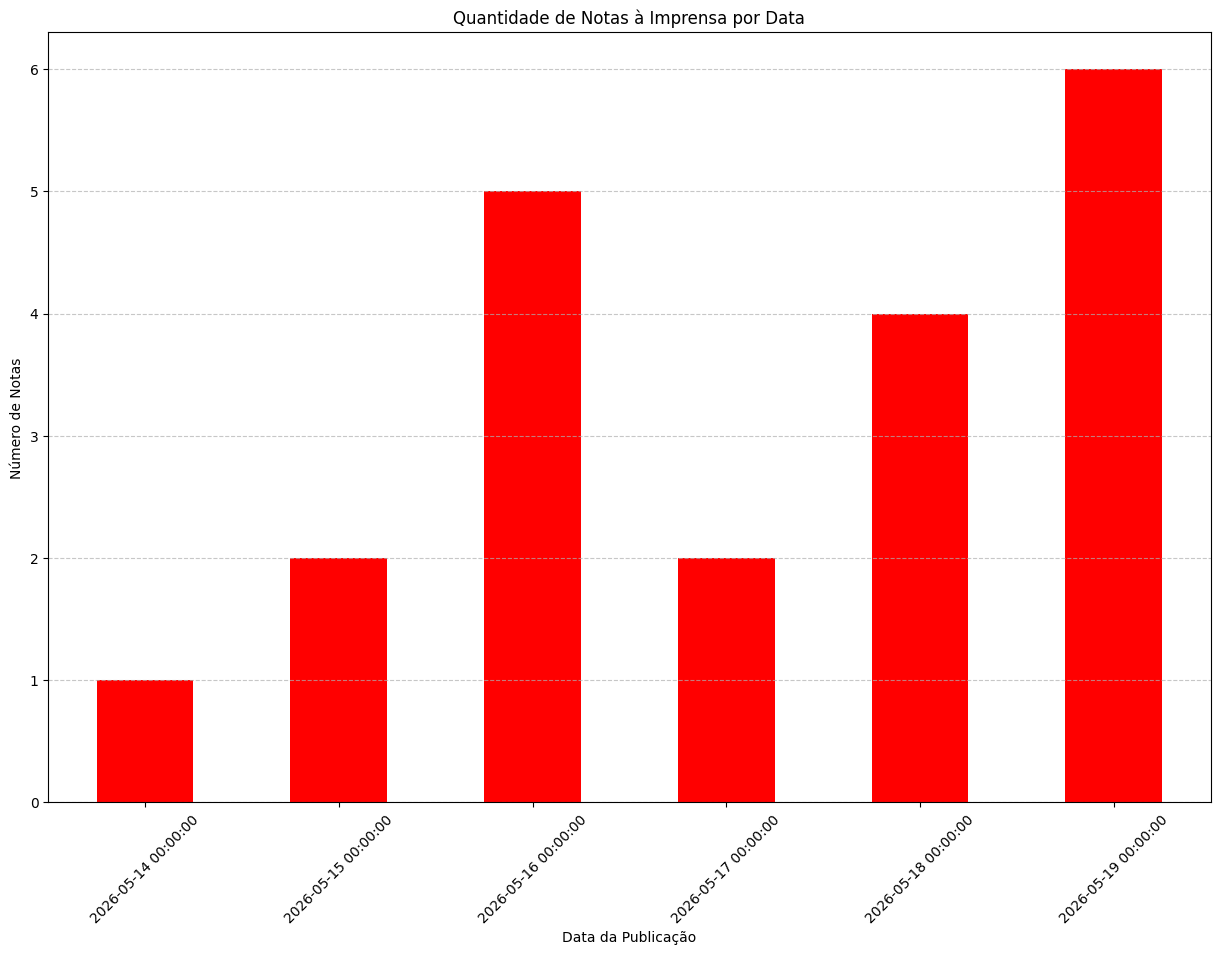

In [56]:
import matplotlib.pyplot as plt

# Criando o gráfico
plt.figure(figsize=(15, 10))
noticias_por_dia.plot(kind='bar', color='red')

# Adicionando títulos e rótulos
plt.title('Quantidade de Notas à Imprensa por Data')
plt.xlabel('Data da Publicação')
plt.ylabel('Número de Notas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

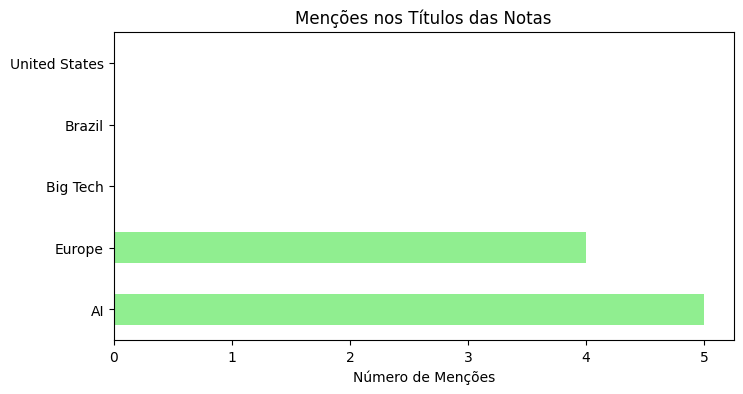

In [57]:
temas = ['AI', 'Big Tech', 'Brazil', 'United States', 'Europe']
frequencia = {}

for tema_singular in temas:
    # Conta em quantos títulos a palavra aparece
    frequencia[tema_singular] = df['titulo'].str.contains(tema_singular, case=False).sum()

# Converter para série para facilitar a plotagem
ser_freq = pd.Series(frequencia)

plt.figure(figsize=(8, 4))
ser_freq.sort_values(ascending=False).plot(kind='barh', color='lightgreen')
plt.title('Menções nos Títulos das Notas')
plt.xlabel('Número de Menções')
plt.show()

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# 1.1 — Converter data para datetime (dayfirst pq é formato brasileiro: dd/mm/aaaa)
df['data_dt'] = pd.to_datetime(df['data'], dayfirst=True, errors='coerce')

# 1.2 — Juntar os parágrafos (que são listas) em um único texto
df['texto'] = df['paragrafo'].apply(lambda lista: ' '.join(lista) if isinstance(lista, list) else str(lista))

# 1.3 — Coluna com tudo junto e em minúsculas (facilita buscas)
df['texto_completo'] = (df['titulo'].fillna('') + ' ' + df['texto']).str.lower()

# 1.4 — Extrair a hora como número inteiro (de "19h20" tira o 19)
df['hora_int'] = df['hora'].str.extract(r'(\d{1,2})').astype(float)

# 1.5 — Colunas auxiliares de tempo
df['ano_mes'] = df['data_dt'].dt.to_period('M')
df['dia_semana'] = df['data_dt'].dt.day_name()
df['tamanho_texto'] = df['texto'].str.len()
df['qtd_paragrafos'] = df['paragrafo'].apply(lambda x: len(x) if isinstance(x, list) else 0)

print(f"Total de notas: {len(df)}")
print(f"Período: de {df['data_dt'].min().date()} até {df['data_dt'].max().date()}")
df[['titulo', 'data_dt', 'hora_int', 'qtd_paragrafos', 'tamanho_texto']].head()

Total de notas: 20
Período: de 2026-05-14 até 2026-05-19


/tmp/ipykernel_14816/623836637.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['data_dt'] = pd.to_datetime(df['data'], dayfirst=True, errors='coerce')


,titulo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
1,Chinese scientists unveil young pulsar's origi...,2026-05-19,23.0,10,2378
2,Successful launch in landmark China-Europe joi...,2026-05-19,16.0,5,969
3,China Focus: SMILE in sky: a new chapter in Ch...,2026-05-19,14.0,36,8633
4,Urgent: China-Europe joint SMILE satellite mis...,2026-05-19,13.0,1,305
5,Flash: China-Europe joint SMILE satellite miss...,2026-05-19,12.0,2,91


In [59]:
# Duplicatas por link (cada nota deveria ter um link único)
print("Duplicatas por link:", df.duplicated(subset=['link']).sum())

# Duplicatas por título
print("Duplicatas por título:", df.duplicated(subset=['titulo']).sum())

Duplicatas por link: 0
Duplicatas por título: 0


In [60]:
def buscar_termo(termo, onde='completo', mostrar=5):
    """
    Busca um termo nas notas do MRE.

    Parâmetros:
        termo (str): palavra ou expressão a buscar (não diferencia maiúsc/minúsc)
        onde (str): 'titulo', 'texto' ou 'completo' (título + corpo)
        mostrar (int): quantos resultados imprimir

    Retorna:
        DataFrame com as notas que contêm o termo
    """
    coluna = {
        'titulo': 'titulo',
        'texto': 'texto',
        'completo': 'texto_completo',
    }[onde]

    # busca case-insensitive; na=False ignora valores faltantes
    mascara = df[coluna].str.contains(termo, case=False, na=False, regex=False)
    resultado = df[mascara].sort_values('data_dt', ascending=False)

    print(f"🔎 Termo: '{termo}'  |  Onde: {onde}")
    print(f"📌 Notas encontradas: {len(resultado)} de {len(df)} ({len(resultado)/len(df)*100:.1f}%)")
    print("-" * 60)

    for _, row in resultado.head(mostrar).iterrows():
        data_str = row['data_dt'].strftime('%d/%m/%Y') if pd.notna(row['data_dt']) else '?'
        print(f"  • [{data_str}] {row['titulo']}")

    if len(resultado) > mostrar:
        print(f"  ... e mais {len(resultado) - mostrar} nota(s)")

    return resultado


# Exemplos de uso:
res = buscar_termo('AI', onde='completo', mostrar=5)

🔎 Termo: 'AI'  |  Onde: completo
📌 Notas encontradas: 13 de 20 (65.0%)
------------------------------------------------------------
  • [19/05/2026] China Focus: SMILE in sky: a new chapter in China-Europe space science cooperation2026-05-19 14:44:30
  • [19/05/2026] Across China: New study provides scientific basis for sustainable grazing management on Qinghai-Tibet Plateau2026-05-19 11:38:30
  • [18/05/2026] China Focus: China hits new milestone in space solar power project2026-05-18 21:50:00
  • [18/05/2026] Across China: Chinese researchers construct "biological pacemaker" to control heartbeat2026-05-18 19:12:15
  • [18/05/2026] China Focus: Chinese scientists unveil decadal-scale thermal memory of permafrost on Qinghai-Tibet Plateau2026-05-18 19:05:45
  ... e mais 8 nota(s)


In [61]:
# Buscar só no título
buscar_termo('AI', onde='titulo', mostrar=5)

🔎 Termo: 'AI'  |  Onde: titulo
📌 Notas encontradas: 5 de 20 (25.0%)
------------------------------------------------------------
  • [19/05/2026] Across China: New study provides scientific basis for sustainable grazing management on Qinghai-Tibet Plateau2026-05-19 11:38:30
  • [18/05/2026] China Focus: Chinese scientists unveil decadal-scale thermal memory of permafrost on Qinghai-Tibet Plateau2026-05-18 19:05:45
  • [17/05/2026] China launches new batch of satellite for Spacesail Constellation2026-05-17 23:46:00
  • [16/05/2026] China Focus: China launches national vocational training ground for embodied robots2026-05-16 21:27:30
  • [14/05/2026] China achieves successful batch cloning of super high-yield dairy goats2026-05-14 22:51:45


,titulo,link,data,hora,paragrafo,data_dt,texto,texto_completo,hora_int,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos
6,Across China: New study provides scientific ba...,https://english.news.cn/../20260519/98e358eb10...,2026-05-19,11:38:30,"[LANZHOU, May 19 (Xinhua) -- A new study by Ch...",2026-05-19,"LANZHOU, May 19 (Xinhua) -- A new study by Chi...",across china: new study provides scientific ba...,11.0,2026-05,Tuesday,2978,9
9,China Focus: Chinese scientists unveil decadal...,https://english.news.cn/../20260518/deb11b378f...,2026-05-18,19:05:45,"[LANZHOU, May 18 (Xinhua) -- A new study by Ch...",2026-05-18,"LANZHOU, May 18 (Xinhua) -- A new study by Chi...",china focus: chinese scientists unveil decadal...,19.0,2026-05,Monday,3557,13
11,China launches new batch of satellite for Spac...,https://english.news.cn/../20260517/7f4461dda8...,2026-05-17,23:46:00,"[, A Long March-8 carrier rocket carrying a ne...",2026-05-17,A Long March-8 carrier rocket carrying a new ...,china launches new batch of satellite for spac...,23.0,2026-05,Sunday,2640,12
13,China Focus: China launches national vocationa...,https://english.news.cn/../20260516/700afeaa52...,2026-05-16,21:27:30,"[HANGZHOU, May 16 (Xinhua) -- A national pilot...",2026-05-16,"HANGZHOU, May 16 (Xinhua) -- A national pilot ...",china focus: china launches national vocationa...,21.0,2026-05,Saturday,2360,8
20,China achieves successful batch cloning of sup...,https://english.news.cn/../20260514/11765722a0...,2026-05-14,22:51:45,"[, Members of a research team from the Northwe...",2026-05-14,Members of a research team from the Northwest...,china achieves successful batch cloning of sup...,22.0,2026-05,Thursday,3031,13


In [62]:
# Buscar uma expressão composta
buscar_termo('Big Tech', onde='completo', mostrar=5)

🔎 Termo: 'Big Tech'  |  Onde: completo
📌 Notas encontradas: 0 de 20 (0.0%)
------------------------------------------------------------


,titulo,link,data,hora,paragrafo,data_dt,texto,texto_completo,hora_int,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos


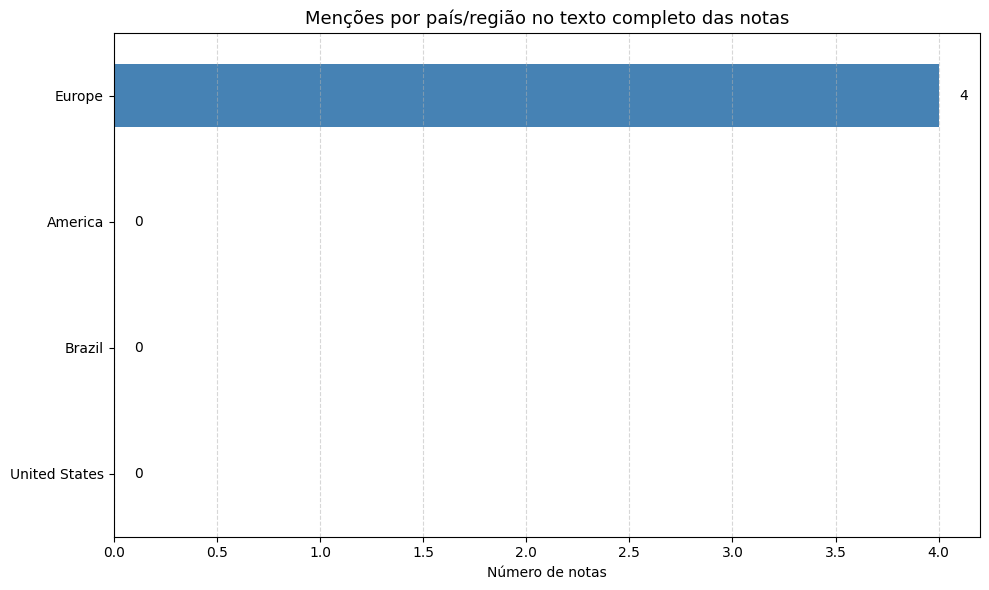

In [63]:
def frequencia_termos(lista_termos, onde='completo'):
    """Conta em quantas notas cada termo da lista aparece."""
    coluna = {'titulo': 'titulo', 'texto': 'texto', 'completo': 'texto_completo'}[onde]
    freq = {}
    for termo in lista_termos:
        freq[termo] = df[coluna].str.contains(termo, case=False, na=False, regex=False).sum()
    return pd.Series(freq).sort_values(ascending=True)


# Lista mais ampla de países e temas
termos_interesse = [
    'United States', 'Brazil', 'Europe', 'America'
]

freq = frequencia_termos(termos_interesse, onde='completo')

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
freq.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Menções por país/região no texto completo das notas', fontsize=13)
ax.set_xlabel('Número de notas')
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Anotar valores nas barras
for i, valor in enumerate(freq.values):
    ax.text(valor + 0.1, i, str(valor), va='center')

plt.tight_layout()
plt.show()

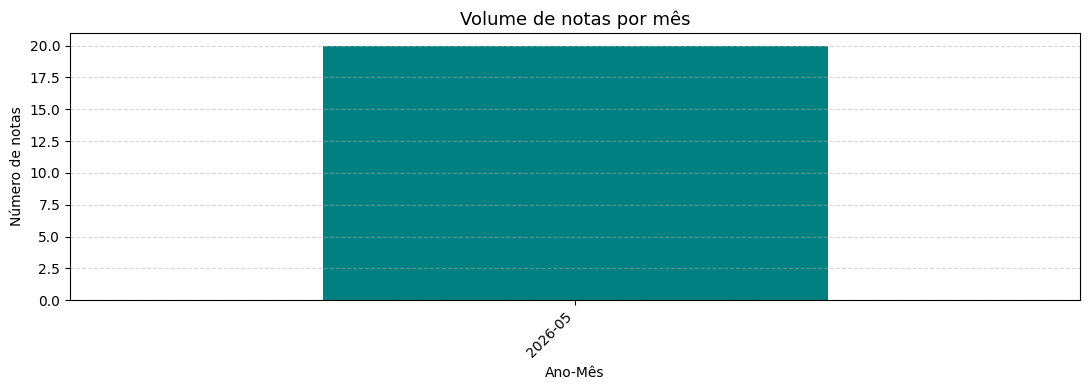

In [64]:
# Notas por mês
notas_por_mes = df.groupby('ano_mes').size()

fig, ax = plt.subplots(figsize=(11, 4))
notas_por_mes.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Volume de notas por mês', fontsize=13)
ax.set_xlabel('Ano-Mês')
ax.set_ylabel('Número de notas')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()